In [1]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q /content/drive/MyDrive/realwaste.zip -d /content/realwaste/

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import glob
import pandas as pd
from sklearn.metrics import silhouette_score
from tqdm.notebook import tqdm


def hitung_jarak(X, centroids, metric='euclidean', p=3):
    d = X[:, np.newaxis, :] - centroids

    if metric == 'euclidean':
        return np.sqrt((d ** 2).sum(axis=2))

    if metric == 'manhattan':
        return np.abs(d).sum(axis=2)

    if metric == 'minkowski':
        return (np.abs(d) ** p).sum(axis=2) ** (1 / p)

    raise ValueError(f"Metrik tidak dikenal: {metric}")


def kmeans_custom(X, k=2, metric='euclidean', p=3, max_iters=30, tol=1e-4):
    np.random.seed(42)

    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        labels = np.argmin(hitung_jarak(X, centroids, metric, p), axis=1)

        centroids_baru = np.array([
            X[labels == i].mean(axis=0)
            if (labels == i).any()
            else centroids[i]
            for i in range(k)
        ])

        if np.all(np.abs(centroids_baru - centroids) < tol):
            break

        centroids = centroids_baru

    return centroids, labels


def interpretasi_sampah(centroids):
    skor = [
        (10 if 0.05 <= h <= 0.48 else 0) +
        (2 if 0.2 <= s <= 0.7 else 0)
        for h, s, _ in centroids
    ]

    if skor[0] != skor[1]:
        idx_organik = int(np.argmax(skor))
    else:
        idx_organik = int(np.argmin(centroids[:, 1]))

    return idx_organik, 1 - idx_organik


FOLDER_ORGANIK = {'food organics', 'vegetation'}


def ambil_label_asli(path_gambar):
    nama_folder = os.path.basename(os.path.dirname(path_gambar)).lower()
    return 'Organik' if nama_folder in FOLDER_ORGANIK else 'Anorganik'


def proses_satu_gambar_kmeans(path_gambar, metric='euclidean'):
    img_bgr = cv2.imread(path_gambar)

    if img_bgr is None:
        return None

    img_resized = cv2.resize(img_bgr, (150, 150))

    img_hsv = cv2.cvtColor(
        cv2.GaussianBlur(img_resized, (5, 5), 0),
        cv2.COLOR_BGR2HSV
    )

    h, w, _ = img_hsv.shape

    piksel = img_hsv.reshape(-1, 3).astype(np.float32)
    piksel /= np.array([179.0, 255.0, 255.0])

    mulai = time.perf_counter()

    centroids, labels = kmeans_custom(piksel, metric=metric)

    waktu = time.perf_counter() - mulai

    silhouette = silhouette_score(
        piksel,
        labels,
        sample_size=2000,
        random_state=42
    )

    idx_org, idx_anorg = interpretasi_sampah(centroids)

    warna = {'organik': [0, 255, 0], 'anorganik': [0, 0, 255]}
    seg = np.zeros((len(labels), 3), dtype=np.uint8)
    seg[labels == idx_org] = warna['organik']
    seg[labels == idx_anorg] = warna['anorganik']
    hasil_seg = seg.reshape(h, w, 3)

    proporsi_organik = np.sum(labels == idx_org) / len(labels)
    prediksi = 'Organik' if proporsi_organik >= 0.5 else 'Anorganik'

    return {
        'img_resized': img_resized,
        'hasil_seg': hasil_seg,
        'prediksi': prediksi,
        'waktu': waktu,
        'silhouette': silhouette,
        'metric': metric
    }


Total gambar ditemukan: 4752


K-Means Batch:   0%|          | 0/4752 [00:00<?, ?it/s]

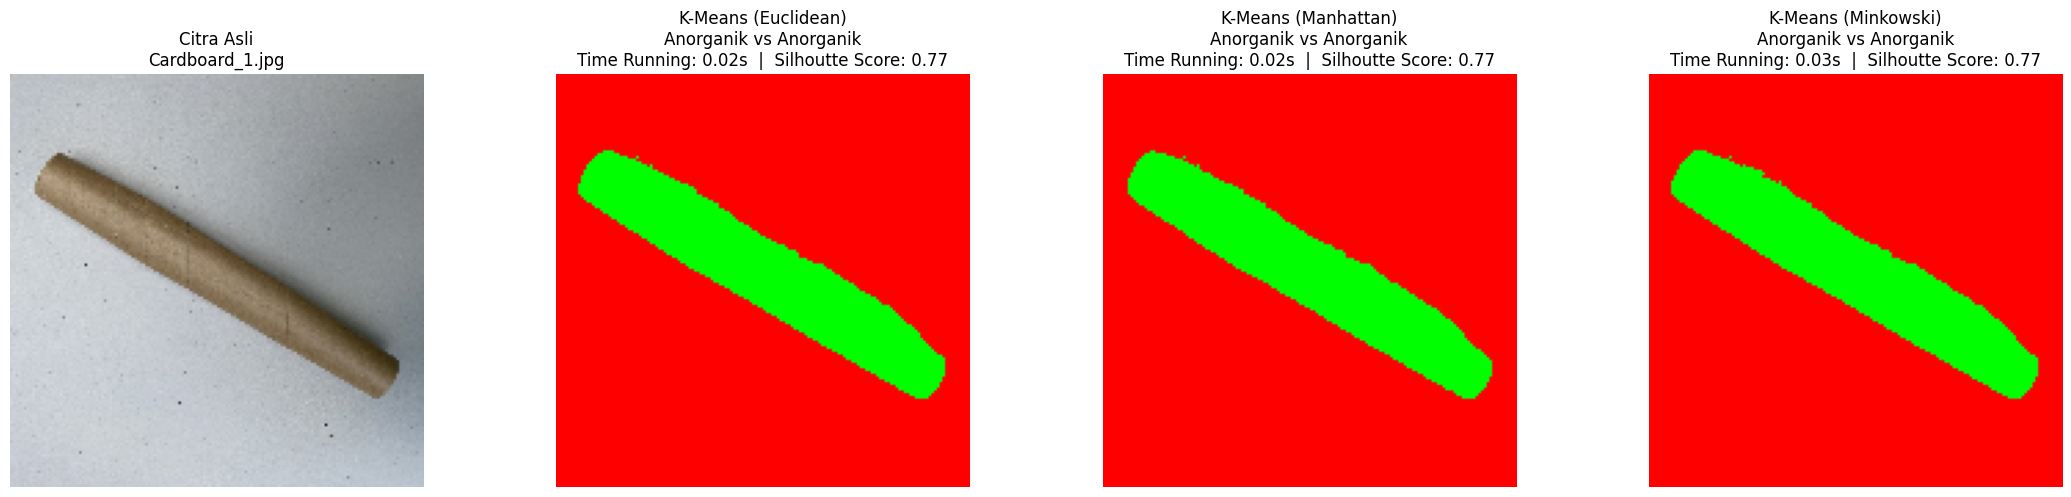

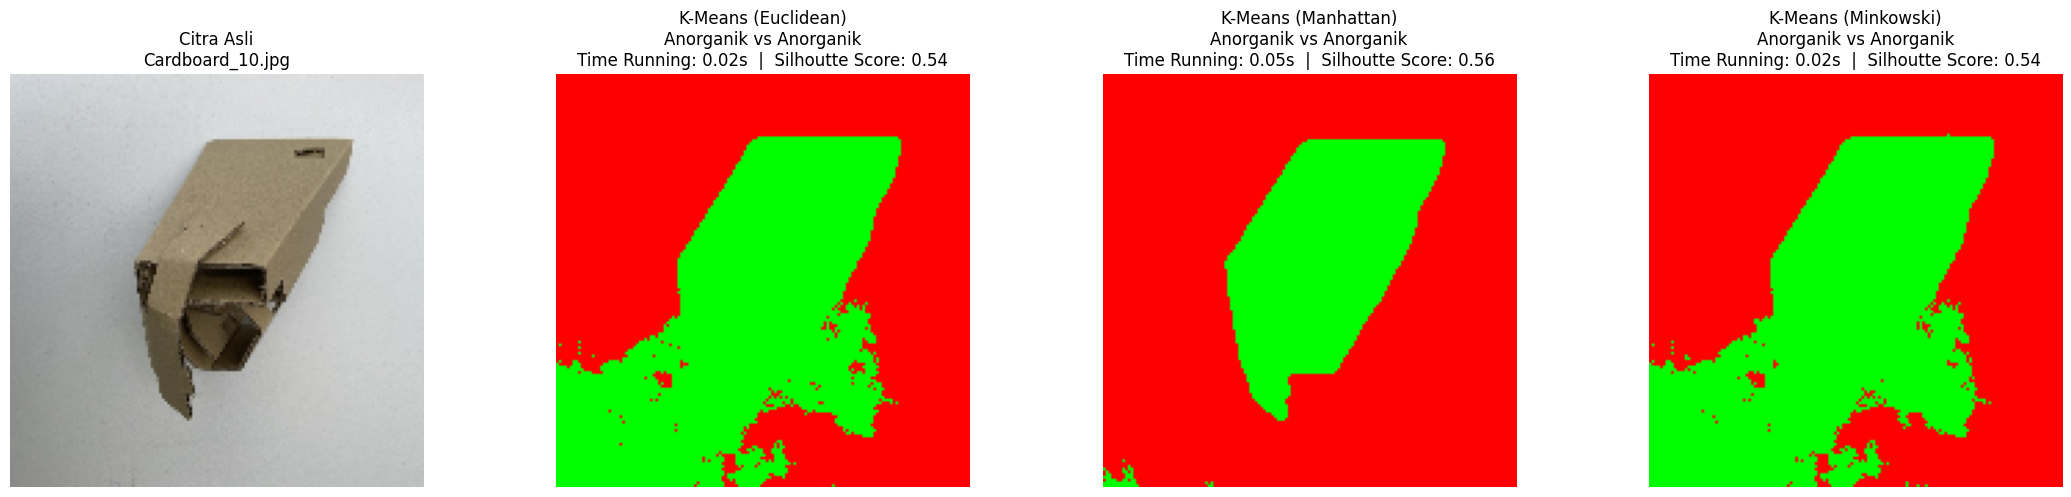

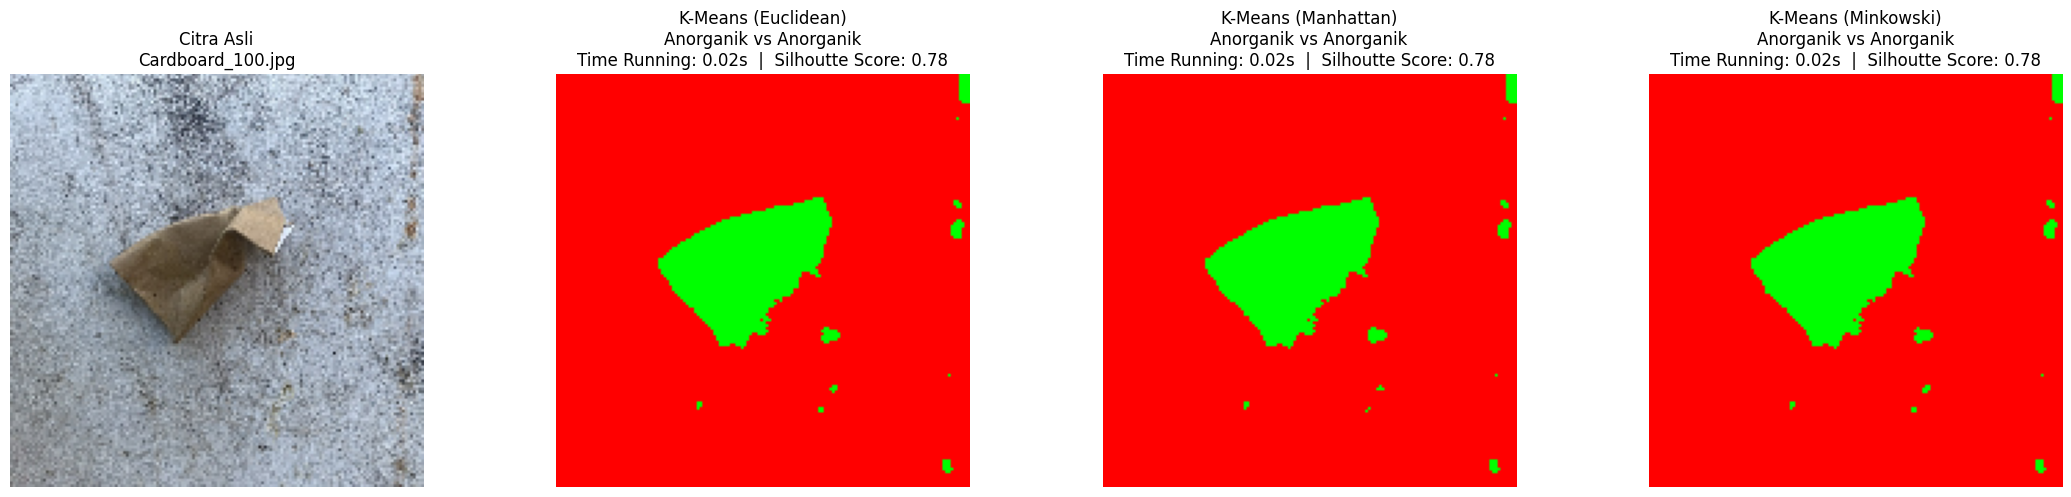

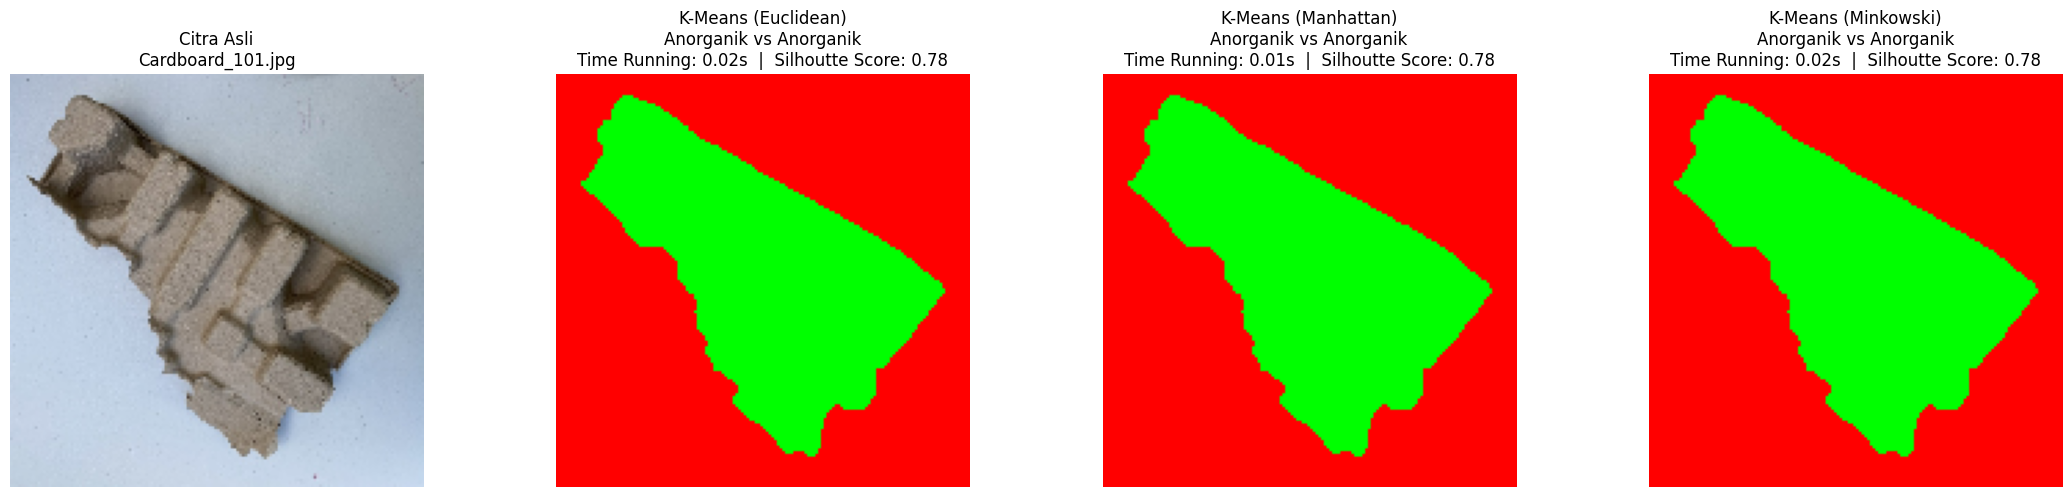

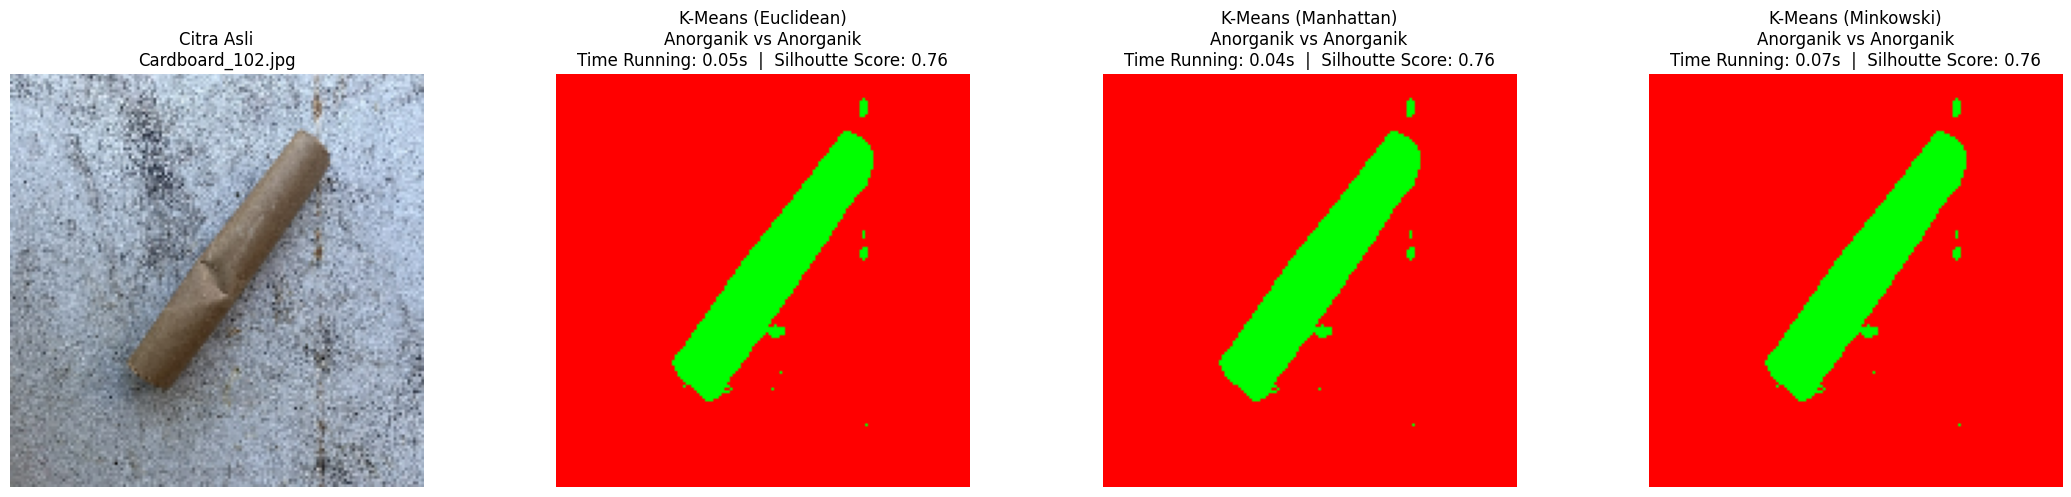


Ekspor selesai: /content/drive/MyDrive/rekapan_evaluasi_KMEANS.csv
Total baris terekap: 14256

Ringkasan Akurasi per Metrik:
Metrik Jarak
Euclidean    41.75
Manhattan    43.24
Minkowski    41.50
Name: Akurasi (%), dtype: float64


,Nama File,Label Asli,Hasil Prediksi Model,Algoritma,Metrik Jarak,Waktu Eksekusi (s),Silhouette Score,Akurasi (%)
0,Cardboard_1.jpg,Anorganik,Anorganik,K-Means,Euclidean,0.0247,0.7655,100
1,Cardboard_1.jpg,Anorganik,Anorganik,K-Means,Manhattan,0.0241,0.7658,100
2,Cardboard_1.jpg,Anorganik,Anorganik,K-Means,Minkowski,0.0295,0.7655,100
3,Cardboard_10.jpg,Anorganik,Anorganik,K-Means,Euclidean,0.0203,0.5439,100
4,Cardboard_10.jpg,Anorganik,Anorganik,K-Means,Manhattan,0.0514,0.5637,100
5,Cardboard_10.jpg,Anorganik,Anorganik,K-Means,Minkowski,0.0175,0.5441,100
6,Cardboard_100.jpg,Anorganik,Anorganik,K-Means,Euclidean,0.0204,0.7768,100
7,Cardboard_100.jpg,Anorganik,Anorganik,K-Means,Manhattan,0.0197,0.7768,100
8,Cardboard_100.jpg,Anorganik,Anorganik,K-Means,Minkowski,0.0224,0.7771,100
9,Cardboard_101.jpg,Anorganik,Anorganik,K-Means,Euclidean,0.0156,0.7782,100


In [5]:
FOLDER_DATASET = '/content/realwaste/'
BATAS_VISUALISASI = 5
METRIK_LIST = ['euclidean', 'manhattan', 'minkowski']

semua_gambar = sorted(
    glob.glob(os.path.join(FOLDER_DATASET, '**', '*.jpg'), recursive=True)
)

print(f"Total gambar ditemukan: {len(semua_gambar)}")

rekap_data = []

for nomor_gambar, path in enumerate(tqdm(semua_gambar, desc='K-Means Batch')):
    nama_file = os.path.basename(path)
    label_asli = ambil_label_asli(path)

    hasil_visualisasi = {}

    for metric in METRIK_LIST:
        hasil = proses_satu_gambar_kmeans(path, metric=metric)

        if hasil is None:
            continue

        akurasi = 100 if hasil['prediksi'] == label_asli else 0

        rekap_data.append({
            'Nama File': nama_file,
            'Label Asli': label_asli,
            'Hasil Prediksi Model': hasil['prediksi'],
            'Algoritma': 'K-Means',
            'Metrik Jarak': hasil['metric'].capitalize(),
            'Waktu Eksekusi (s)': round(hasil['waktu'], 4),
            'Silhouette Score': round(hasil['silhouette'], 4),
            'Akurasi (%)': akurasi
        })

        hasil_visualisasi[metric] = {
            'img_resized': hasil['img_resized'],
            'hasil_seg': hasil['hasil_seg'],
            'prediksi': hasil['prediksi'],
            'waktu': hasil['waktu'],
            'silhouette': hasil['silhouette']
        }

    if nomor_gambar < BATAS_VISUALISASI and len(hasil_visualisasi) == len(METRIK_LIST):
        fig, axes = plt.subplots(1, 4, figsize=(22, 5))

        axes[0].imshow(cv2.cvtColor(hasil_visualisasi['euclidean']['img_resized'], cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Citra Asli\n{nama_file}")
        axes[0].axis('off')

        for idx_ax, metric in enumerate(METRIK_LIST, start=1):
            data = hasil_visualisasi[metric]
            axes[idx_ax].imshow(cv2.cvtColor(data['hasil_seg'], cv2.COLOR_BGR2RGB))
            axes[idx_ax].set_title(
                f"K-Means ({metric.capitalize()})\n"
                f"{label_asli} vs {data['prediksi']}\n"
                f"Time Running: {data['waktu']:.2f}s  |  Silhoutte Score: {data['silhouette']:.2f}"
            )
            axes[idx_ax].axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()


df_rekap = pd.DataFrame(rekap_data)

path_output = '/content/drive/MyDrive/rekapan_evaluasi_KMEANS.csv'
df_rekap.to_csv(path_output, index=False)

print(f"\nEkspor selesai: {path_output}")
print(f"Total baris terekap: {len(df_rekap)}")
print(f"\nRingkasan Akurasi per Metrik:")
print(df_rekap.groupby('Metrik Jarak')['Akurasi (%)'].mean().round(2))
df_rekap.head(10)